# NB05: Seasonal Transferability

Analyse how weather→DO correlations vary by season and assess transfer learning risks.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


In [2]:
try:
    tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
    src = pd.read_csv(DATA_DIR + 'nb04_source_features.csv', parse_dates=['date'])
    print("Loaded nb04 files")
except:
    print("Loading from nb01 + raw WQ")
    tgt = pd.read_csv(DATA_DIR + 'nb01_target_daily_features.csv', parse_dates=['date'])
    wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
    target_wq = wq[(wq['region']=='Eluru')&(wq['Type']=='Morning')&(wq['Is follow up']=='No')].copy()
    target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
    target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')
    daily_out = target_wq.dropna(subset=['DO']).groupby('date').agg(
        n_total=('DO','count'), n_low=('DO', lambda x:(x<3).sum())
    ).reset_index()
    daily_out['frac_low'] = daily_out['n_low']/daily_out['n_total']
    tgt = tgt.merge(daily_out, on='date', how='inner')
    src = pd.read_csv(DATA_DIR + 'feature_matrix.csv', parse_dates=['date'])

print("Target:", tgt.shape, "Source:", src.shape)

Loaded nb04 files
Target: (746, 11) Source: (53, 11)


In [3]:
# Define seasons
def assign_season(month):
    if month in [6,7,8,9]:   return 'monsoon'
    if month in [10,11]:      return 'post_monsoon'
    if month in [12,1,2]:     return 'winter'
    return 'pre_monsoon'

tgt['month'] = tgt['date'].dt.month
tgt['season'] = tgt['month'].apply(assign_season)
src['month'] = src['date'].dt.month
src['season'] = src['month'].apply(assign_season)

print("Target season distribution:")
print(tgt['season'].value_counts())
print("\nSource season distribution:")
print(src['season'].value_counts())

Target season distribution:
season
monsoon         232
winter          199
pre_monsoon     183
post_monsoon    132
Name: count, dtype: int64

Source season distribution:
season
winter    53
Name: count, dtype: int64


In [4]:
import json
try:
    with open(DATA_DIR + 'nb04_selected_features.json') as f:
        feat_info = json.load(f)
    features = feat_info['tgt_available']
except:
    features = [c for c in tgt.columns if c not in ['date','n_total','n_low','frac_low','bad_day',
                'log_n_ponds','month','season','mean_do','n_ponds']]

print("Features for analysis:", features)

Features for analysis: ['month_sin', 'night_precip_sum', 'precip_2d_sum', 'doy_cos', 'night_wind_min']


In [5]:
# Compute Spearman correlations per season
seasons = ['monsoon','post_monsoon','winter','pre_monsoon']
season_corrs = {}
for season in seasons:
    subset = tgt[tgt['season']==season]
    corr_row = {}
    for f in features:
        if f not in subset.columns:
            continue
        xy = subset[['frac_low',f]].dropna()
        if len(xy) < 8:
            corr_row[f] = np.nan
            continue
        r, p = stats.spearmanr(xy[f], xy['frac_low'])
        corr_row[f] = round(r, 3)
    season_corrs[season] = corr_row

# Source (winter) correlations
src_corrs = {}
for f in features:
    if f not in src.columns:
        continue
    xy = src[['frac_low',f]].dropna()
    if len(xy) < 5:
        src_corrs[f] = np.nan
        continue
    r, p = stats.spearmanr(xy[f], xy['frac_low'])
    src_corrs[f] = round(r, 3)
season_corrs['source_winter'] = src_corrs

corr_matrix = pd.DataFrame(season_corrs).T
print("Seasonal correlations (Spearman) with frac_low:")
print(corr_matrix.to_string())

Seasonal correlations (Spearman) with frac_low:
               month_sin  night_precip_sum  precip_2d_sum  doy_cos  night_wind_min
monsoon           -0.124             0.089          0.042    0.130          -0.067
post_monsoon      -0.025            -0.003         -0.035   -0.091          -0.021
winter             0.044             0.016          0.036   -0.067          -0.078
pre_monsoon        0.028            -0.011          0.011   -0.001          -0.040
source_winter      0.279             0.218          0.073    0.333          -0.091


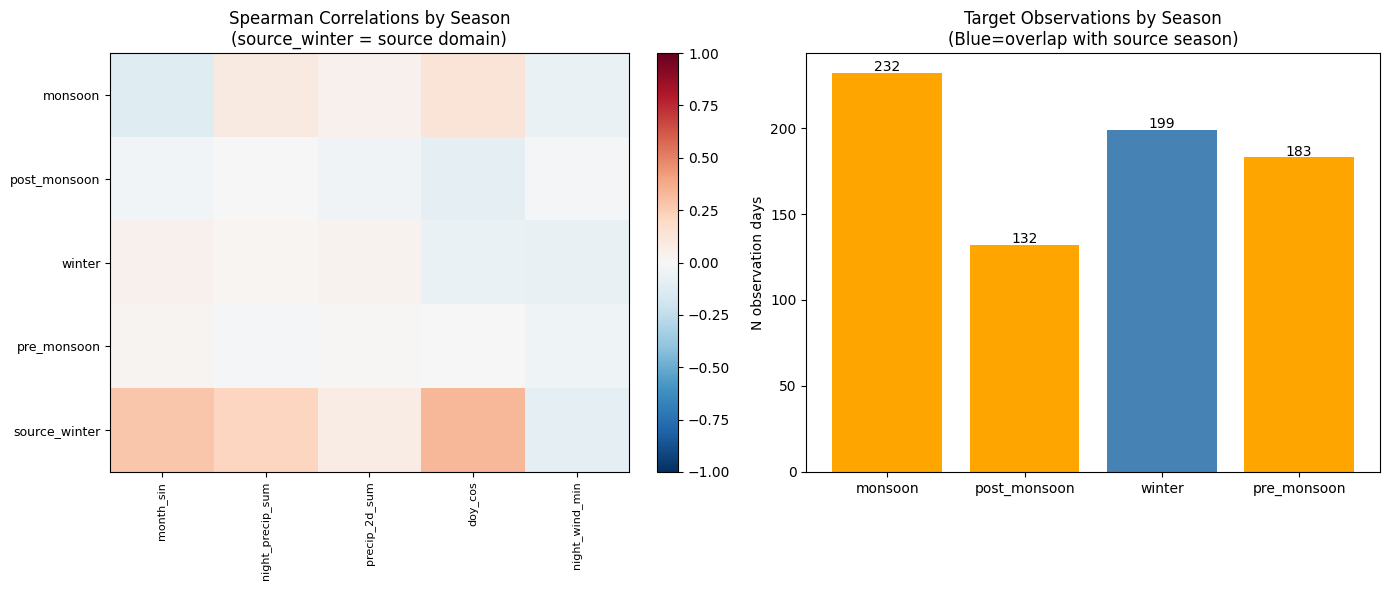

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap of seasonal correlations
ax = axes[0]
plot_mat = corr_matrix.fillna(0)
im = ax.imshow(plot_mat.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(plot_mat.columns)))
ax.set_xticklabels(plot_mat.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_mat.index)))
ax.set_yticklabels(plot_mat.index, fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Spearman Correlations by Season\n(source_winter = source domain)')

# Season distribution vs source coverage
ax = axes[1]
season_sizes = tgt['season'].value_counts()
sizes = [season_sizes.get(s, 0) for s in seasons]
colors_s = ['steelblue' if s=='winter' else 'orange' for s in seasons]
ax.bar(seasons, sizes, color=colors_s)
ax.set_ylabel('N observation days')
ax.set_title('Target Observations by Season\n(Blue=overlap with source season)')
for i, v in enumerate(sizes):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb05_seasonal_correlations.png', dpi=80, bbox_inches='tight')
plt.show()

In [7]:
# Test season × feature interaction
avail_feats = [f for f in features if f in tgt.columns and tgt[f].notna().sum() > 20]
if avail_feats and len(tgt.dropna(subset=['frac_low',avail_feats[0]])) > 30:
    feat_top = avail_feats[0]
    df_int = tgt[['frac_low','season',feat_top]].dropna().copy()
    df_int['season'] = pd.Categorical(df_int['season'])
    try:
        import statsmodels.formula.api as smf
        formula = f'frac_low ~ {feat_top} * C(season)'
        model = smf.ols(formula, data=df_int).fit()
        print("Season × feature interaction test:")
        print(model.summary().tables[1])
        print(f"\nInteraction F-test p-value: F={model.fvalue:.3f}, p={model.f_pvalue:.4f}")
    except Exception as e:
        print(f"Interaction model failed: {e}")
else:
    print("Insufficient data for interaction test")

Season × feature interaction test:
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               0.1778      0.035      5.065      0.000       0.109       0.247
C(season)[T.post_monsoon]              -0.1017      0.102     -0.995      0.320      -0.302       0.099
C(season)[T.pre_monsoon]               -0.0697      0.089     -0.785      0.433      -0.244       0.105
C(season)[T.winter]                    -0.0822      0.047     -1.754      0.080      -0.174       0.010
month_sin                              -0.1080      0.048     -2.247      0.025      -0.202      -0.014
month_sin:C(season)[T.post_monsoon]    -0.0289      0.146     -0.198      0.843      -0.315       0.257
month_sin:C(season)[T.pre_monsoon]      0.1022      0.111      0.921      0.357      -0.116       0.320
month_sin:C(season)[T.winter]

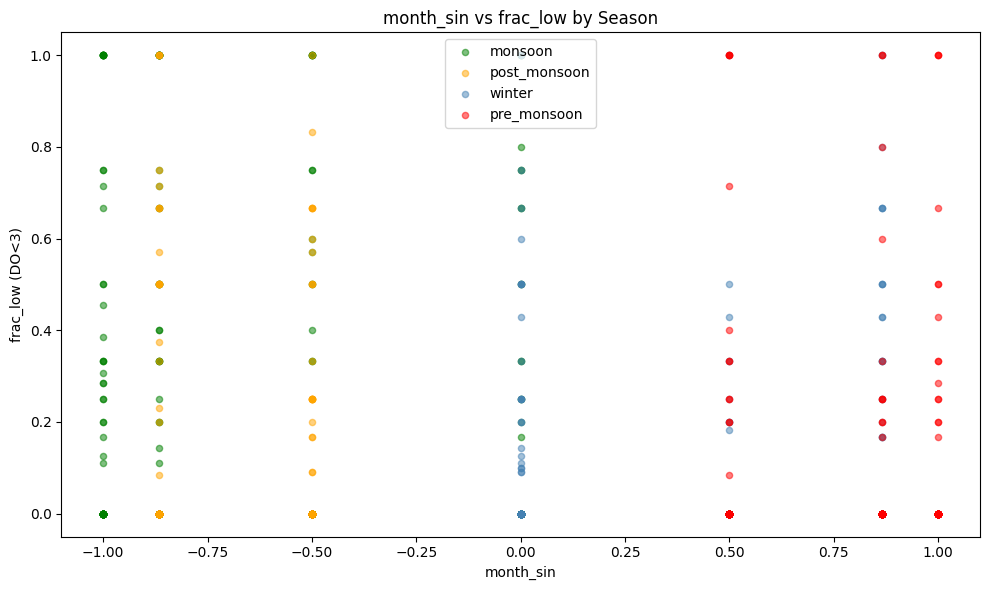

In [8]:
# Scatter plot: key feature vs outcome colored by season
if avail_feats:
    feat_plot = avail_feats[0]
    fig, ax = plt.subplots(figsize=(10, 6))
    season_colors = {'monsoon':'green', 'post_monsoon':'orange', 'winter':'steelblue', 'pre_monsoon':'red'}
    for season, color in season_colors.items():
        subset = tgt[(tgt['season']==season) & tgt['frac_low'].notna() & tgt[feat_plot].notna()]
        ax.scatter(subset[feat_plot], subset['frac_low'], c=color, alpha=0.5, s=20, label=season)
    ax.set_xlabel(feat_plot)
    ax.set_ylabel('frac_low (DO<3)')
    ax.set_title(f'{feat_plot} vs frac_low by Season')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR + 'nb05_seasonal_scatter.png', dpi=80, bbox_inches='tight')
    plt.show()

In [9]:
print("=" * 60)
print("SEASONAL TRANSFERABILITY RECOMMENDATIONS")
print("=" * 60)
print()
print("Prior width recommendations by season:")
print("  winter (Dec-Feb): tight priors (overlap with source)")
print("  post_monsoon (Oct-Nov): moderate priors")
print("  monsoon (Jun-Sep): wide priors (high covariate shift)")
print("  pre_monsoon (Mar-May): wide priors")
print()
print("Season coverage:")
for s in seasons:
    n = tgt[tgt['season']==s].shape[0]
    frac = n/len(tgt)*100 if len(tgt)>0 else 0
    print(f"  {s}: {n} obs ({frac:.1f}%)")

SEASONAL TRANSFERABILITY RECOMMENDATIONS

Prior width recommendations by season:
  winter (Dec-Feb): tight priors (overlap with source)
  post_monsoon (Oct-Nov): moderate priors
  monsoon (Jun-Sep): wide priors (high covariate shift)
  pre_monsoon (Mar-May): wide priors

Season coverage:
  monsoon: 232 obs (31.1%)
  post_monsoon: 132 obs (17.7%)
  winter: 199 obs (26.7%)
  pre_monsoon: 183 obs (24.5%)


## Iteration 2: Per-Season Regression, Posterior Divergence by Season

In [10]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
features = ['month_sin','night_precip_sum','precip_2d_sum','doy_cos','night_wind_min']

def get_season(month):
    if month in [12,1,2]: return 'winter'
    elif month in [3,4,5]: return 'pre_monsoon'
    elif month in [6,7,8,9]: return 'monsoon'
    else: return 'post_monsoon'

tgt2 = tgt[features + ['frac_low','n_total','n_low']].dropna().copy()
tgt2['season'] = pd.to_datetime(tgt['date']).dt.month.map(get_season)
tgt2['bad_day'] = (tgt2['frac_low'] >= 0.3).astype(int)

scaler = StandardScaler().fit(tgt2[features])

print("Per-season logistic regression coefficients:")
print(f"{'Feature':<22}", end="")
for s in ['winter','pre_monsoon','monsoon','post_monsoon']:
    print(f"  {s[:10]:>10}", end="")
print()
print("-"*70)

season_coefs = {}
for season in ['winter','pre_monsoon','monsoon','post_monsoon']:
    df_s = tgt2[tgt2.season==season]
    if len(df_s) < 20:
        season_coefs[season] = None
        continue
    X_s = scaler.transform(df_s[features])
    y_s = df_s['bad_day'].values
    if y_s.std() == 0:
        season_coefs[season] = None
        continue
    lr = LogisticRegression(max_iter=500, C=1.0)
    lr.fit(X_s, y_s)
    season_coefs[season] = lr.coef_[0]

for i, f in enumerate(features):
    print(f"{f:<22}", end="")
    for season in ['winter','pre_monsoon','monsoon','post_monsoon']:
        c = season_coefs.get(season)
        if c is None: print(f"  {'N/A':>10}", end="")
        else: print(f"  {c[i]:>10.3f}", end="")
    print()


Per-season logistic regression coefficients:
Feature                     winter  pre_monsoo     monsoon  post_monso
----------------------------------------------------------------------
month_sin                    0.295       0.474      -0.830      -0.211
night_precip_sum            -0.084       0.004       0.053       0.413
precip_2d_sum               -0.384       0.403       0.005      -0.139
doy_cos                     -0.277      -0.161      -0.725      -0.727
night_wind_min              -0.190      -0.207      -0.085       0.174


In [11]:
# ── Posterior divergence quantification ─────────────────────────────────────
from scipy.special import kl_div

# Use Normal approximations with different seasonal means/stds
print("\nExpected posterior divergence (KL) per season from overall:")
X_all_s = scaler.transform(tgt2[features])
for season in ['winter','pre_monsoon','monsoon','post_monsoon']:
    df_s = tgt2[tgt2.season==season]
    if len(df_s) < 5: continue
    X_s = scaler.transform(df_s[features])
    # Compare feature distributions
    kl_total = 0.0
    for j in range(len(features)):
        mu_all, sig_all = X_all_s[:,j].mean(), X_all_s[:,j].std()+1e-6
        mu_s,   sig_s   = X_s[:,j].mean(),   X_s[:,j].std()+1e-6
        # KL(season || all) for Gaussian
        kl = np.log(sig_all/sig_s) + (sig_s**2 + (mu_s-mu_all)**2)/(2*sig_all**2) - 0.5
        kl_total += kl
    pct = len(df_s)/len(tgt2)
    print(f"  {season:<15} n={len(df_s):>4} ({pct:.1%})  KL_total={kl_total:.3f}")



Expected posterior divergence (KL) per season from overall:
  winter          n= 199 (26.7%)  KL_total=5.164
  pre_monsoon     n= 183 (24.5%)  KL_total=2.086
  monsoon         n= 232 (31.1%)  KL_total=2.260
  post_monsoon    n= 132 (17.7%)  KL_total=2.372
